In [62]:
import pandas as pd
import string


# Loading the Dataset

In [63]:
#Load the Dataset
df=pd.read_csv("./train.txt", sep=";", names=["text","emotions"])

In [64]:
#Display the first 10 rows
print("First 10 rows:")
df.head(10)

First 10 rows:


,text,emotions
0,i didnt feel humiliated,sadness
1,i can go from feeling so hopeless to so damned...,sadness
2,im grabbing a minute to post i feel greedy wrong,anger
3,i am ever feeling nostalgic about the fireplac...,love
4,i am feeling grouchy,anger
5,ive been feeling a little burdened lately wasn...,sadness
6,ive been taking or milligrams or times recomme...,surprise
7,i feel as confused about life as a teenager or...,fear
8,i have been with petronas for years i feel tha...,joy
9,i feel romantic too,love


In [65]:
print("Shape of the dataset:")
df.shape

Shape of the dataset:


(16000, 2)

In [66]:
print("Missing values:")
df.isnull().sum()

Missing values:


,0
text,0
emotions,0


# Exploring Target Lables

In [67]:
print("Unique emotions:")
unique_emo=df['emotions'].unique()
print(unique_emo)

Unique emotions:
['sadness' 'anger' 'love' 'surprise' 'fear' 'joy']


In [68]:
from sklearn.preprocessing import LabelEncoder
le=LabelEncoder()
df['emotions']=le.fit_transform(df['emotions'])
df['emotions']

,emotions
0,4
1,4
2,0
3,3
4,0
...,...
15995,4
15996,4
15997,2
15998,0


In [69]:
emotion_label=le.fit_transform(unique_emo)
emotion_label

array([4, 0, 3, 5, 1, 2])

# LowerCasing

In [70]:
print("Before Lowercasing:")
df['text'].head()

Before Lowercasing:


,text
0,i didnt feel humiliated
1,i can go from feeling so hopeless to so damned...
2,im grabbing a minute to post i feel greedy wrong
3,i am ever feeling nostalgic about the fireplac...
4,i am feeling grouchy


In [71]:
df["Lower_text"]=df["text"].apply(lambda txt: txt.lower())
print("After Lowercasing:")
df['Lower_text'].head()

After Lowercasing:


,Lower_text
0,i didnt feel humiliated
1,i can go from feeling so hopeless to so damned...
2,im grabbing a minute to post i feel greedy wrong
3,i am ever feeling nostalgic about the fireplac...
4,i am feeling grouchy


# Removing punctuations

In [72]:
print("Before Removing Punctuation:")
df['text'].head()

Before Removing Punctuation:


,text
0,i didnt feel humiliated
1,i can go from feeling so hopeless to so damned...
2,im grabbing a minute to post i feel greedy wrong
3,i am ever feeling nostalgic about the fireplac...
4,i am feeling grouchy


In [73]:
import string
def remove_punc(txt):
  return txt.translate(str.maketrans('', '', string.punctuation))
df['Punc_text']=df['text'].apply(remove_punc)

In [74]:
print("After Removing Punctuation:")
df['Punc_text'].head()

After Removing Punctuation:


,Punc_text
0,i didnt feel humiliated
1,i can go from feeling so hopeless to so damned...
2,im grabbing a minute to post i feel greedy wrong
3,i am ever feeling nostalgic about the fireplac...
4,i am feeling grouchy


# Remove Numbers

In [75]:
print("Before Removing Numbers:")
df['text'].head()

Before Removing Numbers:


,text
0,i didnt feel humiliated
1,i can go from feeling so hopeless to so damned...
2,im grabbing a minute to post i feel greedy wrong
3,i am ever feeling nostalgic about the fireplac...
4,i am feeling grouchy


In [76]:
def remove_numbers(txt):
  new=""
  for i in txt:
    if not i.isdigit():
      new+=i
  return new
df['Number_text']=df['text'].apply(remove_numbers)
print("After Removing Numbers:")
df['Number_text'].head()

After Removing Numbers:


,Number_text
0,i didnt feel humiliated
1,i can go from feeling so hopeless to so damned...
2,im grabbing a minute to post i feel greedy wrong
3,i am ever feeling nostalgic about the fireplac...
4,i am feeling grouchy


# Removing Emojis nad Special Charcaters

In [77]:

def remove_emojis(txt):
  new=""
  for i in txt:
    if i.isascii():
      new+=i
  return new
df['Emoji_text']=df['text'].apply(remove_emojis)
df['Emoji_text'].head()

,Emoji_text
0,i didnt feel humiliated
1,i can go from feeling so hopeless to so damned...
2,im grabbing a minute to post i feel greedy wrong
3,i am ever feeling nostalgic about the fireplac...
4,i am feeling grouchy


# Removing Stopwords

In [78]:
import nltk
from nltk.corpus import stopwords
nltk.download('stopwords')
stw=set(stopwords.words('english'))



[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


In [79]:
def remove_stopwords(txt):
 words=txt.split()
 cleaned=[]
 for i in words:
  if i not in stw:
    cleaned.append(i)
 return " ".join(cleaned)
df['Stop_text']=df['text'].apply(remove_stopwords)
df['Stop_text'].head()

,Stop_text
0,didnt feel humiliated
1,go feeling hopeless damned hopeful around some...
2,im grabbing minute post feel greedy wrong
3,ever feeling nostalgic fireplace know still pr...
4,feeling grouchy


# Complete Text Cleaninig Pipeline

In [80]:
print("Original Text:")
df['text'].head()

Original Text:


,text
0,i didnt feel humiliated
1,i can go from feeling so hopeless to so damned...
2,im grabbing a minute to post i feel greedy wrong
3,i am ever feeling nostalgic about the fireplac...
4,i am feeling grouchy


In [81]:
def cleaned_text(txt):

  # LowerCasing
  txt=txt.lower()

  # Remove punctuation
  txt=txt.translate(str.maketrans('', '', string.punctuation))

  # Remove Numbers
  new=""
  for i in txt:
    if not i.isdigit():
      new+=i
    txt=new

  # Remove emojis
  new=""
  for i in txt:
    if i.isascii():
      new+=i
  txt= new

  # Remove Stopwords
  words=txt.split()
  cleaned=[]
  for i in words:
    if i not in stw:
     cleaned.append(i)
  txt= " ".join(cleaned)

  return txt








In [83]:
df[['text', 'cleaned_text']].head(10)

,text,cleaned_text
0,i didnt feel humiliated,didnt feel humiliated
1,i can go from feeling so hopeless to so damned...,go feeling hopeless damned hopeful around some...
2,im grabbing a minute to post i feel greedy wrong,im grabbing minute post feel greedy wrong
3,i am ever feeling nostalgic about the fireplac...,ever feeling nostalgic fireplace know still pr...
4,i am feeling grouchy,feeling grouchy
5,ive been feeling a little burdened lately wasn...,ive feeling little burdened lately wasnt sure
6,ive been taking or milligrams or times recomme...,ive taking milligrams times recommended amount...
7,i feel as confused about life as a teenager or...,feel confused life teenager jaded year old man
8,i have been with petronas for years i feel tha...,petronas years feel petronas performed well ma...
9,i feel romantic too,feel romantic


# Text Length Analysis

In [84]:
df['text_length']=df['cleaned_text'].apply(lambda x:len(x.split()))

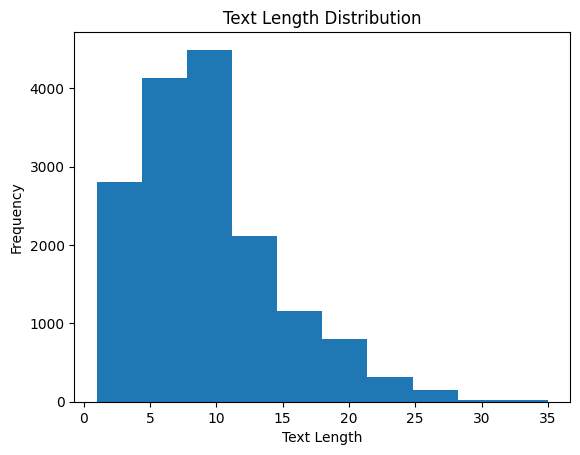

In [86]:
import matplotlib.pyplot as plt
plt.hist(df['text_length'])
plt.title("Text Length Distribution")
plt.xlabel("Text Length")
plt.ylabel("Frequency")
plt.show()

In [87]:
print("Avearge Length:", df['text_length'].mean())
print("Maximum Length:", df['text_length'].max())
print("Minimum Length:", df['text_length'].min())

Avearge Length: 9.3530625
Maximum Length: 35
Minimum Length: 1


# Full Preprocessing pipeline

In [88]:
df[['text', 'Lower_text']].head(10)

,text,Lower_text
0,i didnt feel humiliated,i didnt feel humiliated
1,i can go from feeling so hopeless to so damned...,i can go from feeling so hopeless to so damned...
2,im grabbing a minute to post i feel greedy wrong,im grabbing a minute to post i feel greedy wrong
3,i am ever feeling nostalgic about the fireplac...,i am ever feeling nostalgic about the fireplac...
4,i am feeling grouchy,i am feeling grouchy
5,ive been feeling a little burdened lately wasn...,ive been feeling a little burdened lately wasn...
6,ive been taking or milligrams or times recomme...,ive been taking or milligrams or times recomme...
7,i feel as confused about life as a teenager or...,i feel as confused about life as a teenager or...
8,i have been with petronas for years i feel tha...,i have been with petronas for years i feel tha...
9,i feel romantic too,i feel romantic too


In [89]:
df[['text', 'Punc_text']].head(10)

,text,Punc_text
0,i didnt feel humiliated,i didnt feel humiliated
1,i can go from feeling so hopeless to so damned...,i can go from feeling so hopeless to so damned...
2,im grabbing a minute to post i feel greedy wrong,im grabbing a minute to post i feel greedy wrong
3,i am ever feeling nostalgic about the fireplac...,i am ever feeling nostalgic about the fireplac...
4,i am feeling grouchy,i am feeling grouchy
5,ive been feeling a little burdened lately wasn...,ive been feeling a little burdened lately wasn...
6,ive been taking or milligrams or times recomme...,ive been taking or milligrams or times recomme...
7,i feel as confused about life as a teenager or...,i feel as confused about life as a teenager or...
8,i have been with petronas for years i feel tha...,i have been with petronas for years i feel tha...
9,i feel romantic too,i feel romantic too


In [91]:
df[['text', 'Number_text']].head(10)

,text,Number_text
0,i didnt feel humiliated,i didnt feel humiliated
1,i can go from feeling so hopeless to so damned...,i can go from feeling so hopeless to so damned...
2,im grabbing a minute to post i feel greedy wrong,im grabbing a minute to post i feel greedy wrong
3,i am ever feeling nostalgic about the fireplac...,i am ever feeling nostalgic about the fireplac...
4,i am feeling grouchy,i am feeling grouchy
5,ive been feeling a little burdened lately wasn...,ive been feeling a little burdened lately wasn...
6,ive been taking or milligrams or times recomme...,ive been taking or milligrams or times recomme...
7,i feel as confused about life as a teenager or...,i feel as confused about life as a teenager or...
8,i have been with petronas for years i feel tha...,i have been with petronas for years i feel tha...
9,i feel romantic too,i feel romantic too


In [92]:
df[['text', 'Emoji_text']].head(10)

,text,Emoji_text
0,i didnt feel humiliated,i didnt feel humiliated
1,i can go from feeling so hopeless to so damned...,i can go from feeling so hopeless to so damned...
2,im grabbing a minute to post i feel greedy wrong,im grabbing a minute to post i feel greedy wrong
3,i am ever feeling nostalgic about the fireplac...,i am ever feeling nostalgic about the fireplac...
4,i am feeling grouchy,i am feeling grouchy
5,ive been feeling a little burdened lately wasn...,ive been feeling a little burdened lately wasn...
6,ive been taking or milligrams or times recomme...,ive been taking or milligrams or times recomme...
7,i feel as confused about life as a teenager or...,i feel as confused about life as a teenager or...
8,i have been with petronas for years i feel tha...,i have been with petronas for years i feel tha...
9,i feel romantic too,i feel romantic too


In [93]:
df[['text', 'Stop_text']].head(10)

,text,Stop_text
0,i didnt feel humiliated,didnt feel humiliated
1,i can go from feeling so hopeless to so damned...,go feeling hopeless damned hopeful around some...
2,im grabbing a minute to post i feel greedy wrong,im grabbing minute post feel greedy wrong
3,i am ever feeling nostalgic about the fireplac...,ever feeling nostalgic fireplace know still pr...
4,i am feeling grouchy,feeling grouchy
5,ive been feeling a little burdened lately wasn...,ive feeling little burdened lately wasnt sure
6,ive been taking or milligrams or times recomme...,ive taking milligrams times recommended amount...
7,i feel as confused about life as a teenager or...,feel confused life teenager jaded year old man
8,i have been with petronas for years i feel tha...,petronas years feel petronas performed well ma...
9,i feel romantic too,feel romantic


In [94]:
# Save the cleaned dataset
df.to_csv("cleaned_emotions.csv", index=False)

In [95]:
# Value counts of emotions
print("Value counts of emotions:")
df['emotions'].value_counts()

Value counts of emotions:


,count
emotions,
2,5362
4,4666
0,2159
1,1937
3,1304
5,572
